# Edge Effects Analysis

Loads the WDPA-level parquet, runs summary statistics, ANOVA, mixed models, and generates all publication figures.  
Index is read from `modules/config.py` (`INDEX_NAME`).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'scripts' else Path.cwd()))
warnings.filterwarnings('ignore')

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import geopandas as gpd
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pyproj

from modules import config
from modules.analysis import recategorize_biome
from modules.plotting import classify_trend, create_correlation_plot, create_distribution_plots

IDX = config.INDEX_NAME
FIG_DIR = config.RESULTS_FIGURES
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_txt(name, text):
    path = FIG_DIR / f'{IDX}_{name}.txt'
    path.write_text(text)
    print(f'Saved {path}')

def save_fig(name, fig=None, **kw):
    path = FIG_DIR / f'{IDX}_{name}.png'
    (fig or plt.gcf()).savefig(path, dpi=300, bbox_inches='tight', **kw)
    plt.close('all')
    print(f'Saved {path}')

print(f'Index: {IDX.upper()}  |  {config.INDEX_CONFIGS[IDX]["description"]}')

Index: NDVI  |  Normalized Difference Vegetation Index


## 1 — Load & Prepare Data

In [2]:
wdpa_df = pd.read_parquet(config.RESULTS_DIR / f'wdpa_df_{IDX}.parquet')
wdpa_df['BIOME_NAME'] = wdpa_df['BIOME_NAME'].apply(recategorize_biome)

# Classify temporal trends for both metrics (adds trend_, slope_, p_value_ columns)
for metric in ['edge_extent', 'edge_intensity']:
    suffix = metric.split('_')[1]
    trends = (
        wdpa_df.groupby('WDPA_PID')
        .apply(classify_trend, metric=metric)
        .reset_index()
        .rename(columns={'trend': f'trend_{suffix}', 'slope': f'slope_{suffix}', 'p_value': f'p_value_{suffix}'})
    )
    wdpa_df = wdpa_df.merge(trends, on='WDPA_PID', how='left')

print(f'Rows: {len(wdpa_df):,}  |  PAs: {wdpa_df["WDPA_PID"].nunique():,}')
wdpa_df.head()
#wdpa_df.to_csv(config.RESULTS_DIR / f'wdpa_df_{IDX}_trends.csv', index=False)

Rows: 93,036  |  PAs: 4,046


,WDPA_PID,year,n_trnst,D02,D01,D0m1,D0m2,edge_intensity,edge_extent,gHM_mean,...,geometry_t,AREA_DISSO,PERIMETER,PA_RATIO,trend_extent,slope_extent,p_value_extent,trend_intensity,slope_intensity,p_value_intensity
0,100017,2003,865,0.228921,0.172160,0.596666,0.731519,0.172160,0.605780,0.182738,...,Polygon,3.117771e+09,582579.791312,0.000187,decrease,-0.000271,0.628168,decrease,-0.001196,0.538927
1,100017,2004,857,0.219684,0.197429,0.677738,0.770720,0.197429,0.597433,0.182738,...,Polygon,3.117771e+09,582579.791312,0.000187,decrease,-0.000271,0.628168,decrease,-0.001196,0.538927
2,100017,2005,865,0.252335,0.232848,0.734410,0.769700,0.232848,0.604624,0.182738,...,Polygon,3.117771e+09,582579.791312,0.000187,decrease,-0.000271,0.628168,decrease,-0.001196,0.538927
3,100017,2006,865,0.252208,0.266090,0.701824,0.762234,0.252208,0.625434,0.182738,...,Polygon,3.117771e+09,582579.791312,0.000187,decrease,-0.000271,0.628168,decrease,-0.001196,0.538927
4,100017,2007,848,0.243323,0.208690,0.705725,0.780912,0.208690,0.614387,0.182738,...,Polygon,3.117771e+09,582579.791312,0.000187,decrease,-0.000271,0.628168,decrease,-0.001196,0.538927


## 2 — Summary Statistics

In [3]:
pa = wdpa_df.groupby('WDPA_PID').first()  # one row per PA for counts
pa_mean = wdpa_df.groupby('WDPA_PID')[['edge_extent','edge_intensity']].mean()

lines = [
    f'Unique PAs: {len(pa):,}',
    f'Total transects: {pa["n_trnst"].sum():,.0f}',
    f'Countries (ISO3): {wdpa_df["ISO3"].nunique()}',
    f'Biomes: {wdpa_df["BIOME_NAME"].nunique()}',
    '',
    'PAs per biome:',
    *[f'  {b}: {c:,}' for b, c in pa['BIOME_NAME'].value_counts().items()],
    '',
    'Trend (edge_extent):',
    *[f'  {t}: {n:,}' for t, n in pa['trend_extent'].value_counts().items()],
    '',
    f'edge_extent < 10%: {(pa_mean["edge_extent"]<0.1).sum():,} '
    f'({(pa_mean["edge_extent"]<0.1).mean()*100:.1f}%)',
    f'edge_intensity < 0: {(pa_mean["edge_intensity"]<0).sum():,} '
    f'({(pa_mean["edge_intensity"]<0).mean()*100:.1f}%)',
]
summary_txt = '\n'.join(lines)
print(summary_txt)
save_txt('summary_statistics', summary_txt)

Unique PAs: 4,046
Total transects: 1,736,434
Countries (ISO3): 146
Biomes: 8

PAs per biome:
  Grassland & Shrubland: 1,307
  Tropical Forest: 1,166
  Temperate Forest: 712
  Boreal Forest: 371
  Desert: 358
  Tundra: 101
  Mangrove: 14
  Rock & Ice: 10

Trend (edge_extent):
  increase: 1,665
  decrease: 1,501
  sig_increase: 491
  sig_decrease: 388
  no_change: 1

edge_extent < 10%: 1 (0.0%)
edge_intensity < 0: 2,701 (66.8%)
Saved /workspace/results/figures/ndvi_summary_statistics.txt


## 3 — ANOVA

In [4]:
anova_df = wdpa_df[['edge_extent','IUCN_CAT','STATUS_YR','BIOME_NAME','AREA_DISSO']].dropna()

anova_results = []
for factor, formula in [
    ('IUCN_CAT',  'edge_extent ~ C(IUCN_CAT)'),
    ('STATUS_YR',  'edge_extent ~ STATUS_YR'),
    ('BIOME_NAME', 'edge_extent ~ C(BIOME_NAME)'),
    ('AREA_DISSO', 'edge_extent ~ AREA_DISSO'),
]:
    res = anova_lm(ols(formula, data=anova_df).fit(), typ=2)
    header = f'ANOVA for {factor}:\n{res}\n'
    print(header)
    anova_results.append(header)

save_txt('anova_results', '\n'.join(anova_results))

ANOVA for IUCN_CAT:
                 sum_sq       df         F         PR(>F)
C(IUCN_CAT)    6.046756      9.0  97.85566  6.858024e-183
Residual     637.596650  92865.0       NaN            NaN

ANOVA for STATUS_YR:
               sum_sq       df          F        PR(>F)
STATUS_YR    0.539516      1.0  77.913437  1.094748e-18
Residual   643.103890  92873.0        NaN           NaN

ANOVA for BIOME_NAME:
                   sum_sq       df           F  PR(>F)
C(BIOME_NAME)   16.168319      7.0  341.846985     0.0
Residual       627.475086  92867.0         NaN     NaN

ANOVA for AREA_DISSO:
                sum_sq       df         F        PR(>F)
AREA_DISSO    1.223612      1.0  176.8945  2.514527e-40
Residual    642.419793  92873.0       NaN           NaN

Saved /workspace/results/figures/ndvi_anova_results.txt


## 4 — Mixed-Effects Models

In [5]:
# Question #1: What is the trend in edge extent over time, and does it differ by biome?
# edge_extent ~ year_z * C(BIOME_NAME) + (1|WDPA_PID)

exclude_biomes = ['Mangrove', 'Rock & Ice']
df_q1 = (wdpa_df[~wdpa_df['BIOME_NAME'].isin(exclude_biomes)]
         [['edge_extent', 'year', 'BIOME_NAME', 'WDPA_PID']].dropna().copy())
df_q1['year_z'] = (df_q1['year'] - df_q1['year'].mean()) / df_q1['year'].std()

mdf_trend = MixedLM.from_formula(
    'edge_extent ~ year_z * C(BIOME_NAME)',
    data=df_q1, groups=df_q1['WDPA_PID'], re_formula='1'
).fit()
save_txt('edge_extent_trend_model', f"{'='*60}\nMIXED MODEL: TREND x BIOME\n{'='*60}\n\n{mdf_trend.summary()}")
print(mdf_trend.summary())

# --- Compute slope (rate of change) per biome with 95% CI ---
fe = mdf_trend.fe_params
cov = mdf_trend.cov_params()
ref_biome = pd.Categorical(df_q1['BIOME_NAME']).categories[0]
biomes = sorted(df_q1['BIOME_NAME'].unique())

rows = []
for b in biomes:
    if b == ref_biome:
        slope = fe['year_z']
        se = np.sqrt(cov.loc['year_z', 'year_z'])
    else:
        int_key = f'year_z:C(BIOME_NAME)[T.{b}]'
        slope = fe['year_z'] + fe[int_key]
        se = np.sqrt(cov.loc['year_z', 'year_z']
                     + cov.loc[int_key, int_key]
                     + 2 * cov.loc['year_z', int_key])
    rows.append({'biome': b, 'slope': slope, 'lo': slope - 1.96*se, 'hi': slope + 1.96*se})

slopes = pd.DataFrame(rows).sort_values('slope')

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Saved /workspace/results/figures/ndvi_edge_extent_trend_model.txt
                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           edge_extent
No. Observations:             92345             Method:                       REML       
No. Groups:                   4015              Scale:                        0.0014     
Min. group size:              23                Log-Likelihood:               161944.3406
Max. group size:              23                Converged:                    Yes        
Mean group size:              23.0                                                       
-----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                      0.534    0.00

In [6]:
# Question # 2: What is influencing the edge extent? 
# edge_extent_2025 ~ z_covariates + + (1|WDPA_PID)

PREDICTORS = ['STATUS_YR','AREA_DISSO','gHM_mean','elevation_mean','slope_mean','water_extent_pct']
KEEP_COLS = PREDICTORS + ['BIOME_NAME','WDPA_PID']

def fit_mixed(response):
    """Fit MixedLM for *response* ~ z-scored predictors + (1|WDPA_PID)."""
    df_filtered = wdpa_df[wdpa_df['year'] == 2025].copy()
    df = df_filtered[[response] + KEEP_COLS].dropna().copy()
    for c in PREDICTORS:
        df[f'{c}_z'] = (df[c] - df[c].mean()) / df[c].std()
    formula = f"{response} ~ " + " + ".join(f'{c}_z' for c in PREDICTORS)
    mdf = MixedLM.from_formula(formula, data=df, groups=df['WDPA_PID'],
                               re_formula='1').fit()
    return mdf, df

models = {}
for resp, label, stem in [
    ('edge_extent',    'EDGE EXTENT',    'edge_extent_model'),
    ('edge_intensity', 'EDGE INTENSITY', 'edge_intensity_model'),
]:
    mdf, mdf_data = fit_mixed(resp)
    models[resp] = (mdf, mdf_data)
    save_txt(stem, f"{'='*60}\nMIXED MODEL: {label}\n{'='*60}\n\n{mdf.summary()}")
    print(mdf.summary(), '\n')


/usr/local/lib/python3.10/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.10/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


Saved /workspace/results/figures/ndvi_edge_extent_model.txt
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  edge_extent
No. Observations:    3785     Method:              REML       
No. Groups:          3785     Scale:               0.0033     
Min. group size:     1        Log-Likelihood:      4097.9229  
Max. group size:     1        Converged:           Yes        
Mean group size:     1.0                                      
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           0.555    0.001 420.724 0.000  0.553  0.558
STATUS_YR_z         0.005    0.001   3.406 0.001  0.002  0.007
AREA_DISSO_z        0.003    0.001   2.348 0.019  0.001  0.006
gHM_mean_z          0.005    0.001   3.475 0.001  0.002  0.008
elevation_mean_z   -0.006    0.002  -3.434 0.001 -0.010 -0.003
slope_me

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


### Diagnostics (VIF, residuals, observed vs fitted)

In [7]:
for resp, (mdf, mdf_data) in models.items():
    stem = f'edge_{resp.split("_")[1]}_model'
    z_cols = [f'{c}_z' for c in PREDICTORS]

    # VIF
    X = mdf_data[z_cols]
    vif = pd.DataFrame({'variable': z_cols,
                        'VIF': [variance_inflation_factor(X.values, i) for i in range(len(z_cols))]})
    print(f'--- {resp} VIF ---'); print(vif, '\n')

    fitted, observed = mdf.fittedvalues, mdf_data[resp]
    resid = observed.values - fitted.values

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(fitted, observed, alpha=.3, s=5)
    lims = [observed.min(), observed.max()]
    axes[0].plot(lims, lims, 'r--')
    axes[0].set(xlabel='Fitted', ylabel='Observed', title=f'Obs v Fitted: {resp}')
    axes[1].hist(resid, bins=50, edgecolor='k')
    axes[1].set(xlabel='Residual', ylabel='Freq', title=f'Residuals: {resp}')
    plt.tight_layout()
    save_fig(f'{stem}_diagnostics')

--- edge_extent VIF ---
             variable       VIF
0         STATUS_YR_z  1.074798
1        AREA_DISSO_z  1.057298
2          gHM_mean_z  1.106759
3    elevation_mean_z  1.876483
4        slope_mean_z  1.905077
5  water_extent_pct_z  1.057172 

Saved /workspace/results/figures/ndvi_edge_extent_model_diagnostics.png
--- edge_intensity VIF ---
             variable       VIF
0         STATUS_YR_z  1.074798
1        AREA_DISSO_z  1.057298
2          gHM_mean_z  1.106759
3    elevation_mean_z  1.876483
4        slope_mean_z  1.905077
5  water_extent_pct_z  1.057172 

Saved /workspace/results/figures/ndvi_edge_intensity_model_diagnostics.png


## 5 — Figures

### Figure 2 — Map of Edge-Extent

In [ ]:
# Load PA geometries and join trend data
gdf = gpd.read_file(config.DATA_INTERMEDIATE / 'wdpa_filtered' / 'wdpa_filtered.shp')
gdf['WDPA_PID'] = gdf['WDPA_PID'].astype(str)
trend_per_pa = wdpa_df.groupby('WDPA_PID')['trend_extent'].first().reset_index()
trend_per_pa['WDPA_PID'] = trend_per_pa['WDPA_PID'].astype(str)
gdf = gdf.merge(trend_per_pa, on='WDPA_PID', how='inner')
gdf_moll = gdf.to_crs('+proj=moll')

# Figure 2b: Global map of edge extent trends by PA (with insets for key regions)

gdf_moll['trend_extent'] = gdf_moll['trend_extent'].replace(
    {'increase': 'not_significant', 'decrease': 'not_significant', 'no_change': 'not_significant'})
cat_order = ['sig_increase', 'not_significant', 'sig_decrease']
cat_labels = {'sig_increase': 'Significant Increase', 'not_significant': 'Not Significant',
              'sig_decrease': 'Significant Decrease'}
colors = {'sig_increase': '#d73027', 'not_significant': '#afab9e', 'sig_decrease': '#4575b4'}
gdf_moll['trend_extent'] = pd.Categorical(gdf_moll['trend_extent'], categories=cat_order, ordered=True)
# gdf_moll.to_file(config.DATA_PROCESSED / 'wdpa_trends_fig2b.gpkg', driver='GPKG')

# World outline
world = gpd.read_file(
    'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
).to_crs('+proj=moll')

# --- Inset region definitions (lon_min, lon_max, lat_min, lat_max) in WGS84 ---
# All regions use uniform 30° lon x 30° lat
inset_regions = {
    'A': {'bounds': (-125, -95, 25, 55)},    # Western US / N. America
    'B': {'bounds': (-75, -45, -20, 10)},    # Amazon
    'C': {'bounds': (5, 35, 34, 64)},        # Central Europe (centered on Slovakia)
    'D': {'bounds': (25, 55, -20, 10)},      # East Africa
    'E': {'bounds': (95, 125, -5, 25)},      # SE Asia
}

# Project WGS84 bounds to Mollweide
proj_moll = pyproj.Transformer.from_crs('EPSG:4326', '+proj=moll', always_xy=True)

fig = plt.figure(figsize=(18, 14))
# Main map in the upper portion
ax_main = fig.add_axes([0.02, 0.30, 0.96, 0.68])
world.plot(ax=ax_main, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)
for cat in cat_order:
    subset = gdf_moll[gdf_moll['trend_extent'] == cat]
    if len(subset):
        subset.plot(ax=ax_main, color=colors[cat], markersize=4)
ax_main.set_axis_off()
handles = [Patch(facecolor=colors[c], label=cat_labels[c]) for c in cat_order]
ax_main.legend(handles=handles, title='Change in Edge Extent (2003–2025)',
               loc='lower left', frameon=True, fontsize=9)
ax_main.set_title('Figure 2b: Edge Extent Trends by Protected Area', fontsize=14)

# Draw rectangles on main map for each inset
rect_color = '#333333'
for key, info in inset_regions.items():
    lon0, lon1, lat0, lat1 = info['bounds']
    corners_lon = [lon0, lon1, lon1, lon0, lon0]
    corners_lat = [lat0, lat0, lat1, lat1, lat0]
    mx, my = proj_moll.transform(corners_lon, corners_lat)
    ax_main.plot(mx, my, color=rect_color, lw=1.5, ls='-')
    cx, cy = proj_moll.transform((lon0 + lon1) / 2, lat1 + 2)
    ax_main.text(cx, cy, key, fontsize=10, fontweight='bold', ha='center', va='bottom', color=rect_color)

# Create inset axes along the bottom
n_insets = len(inset_regions)
inset_w = 0.17
inset_h = 0.22
gap = (0.96 - n_insets * inset_w) / (n_insets + 1)

for i, (key, info) in enumerate(inset_regions.items()):
    x0 = 0.02 + gap + i * (inset_w + gap)
    ax_in = fig.add_axes([x0, 0.03, inset_w, inset_h])

    lon0, lon1, lat0, lat1 = info['bounds']
    x_min, y_min = proj_moll.transform(lon0, lat0)
    x_max, y_max = proj_moll.transform(lon1, lat1)

    world.plot(ax=ax_in, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)
    for cat in cat_order:
        subset = gdf_moll[gdf_moll['trend_extent'] == cat]
        if len(subset):
            subset.plot(ax=ax_in, color=colors[cat], markersize=8)

    ax_in.set_xlim(x_min, x_max)
    ax_in.set_ylim(y_min, y_max)
    ax_in.set_axis_off()
    ax_in.set_title(key, fontsize=11, fontweight='bold')
    for spine in ax_in.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(rect_color)
        spine.set_linewidth(1.5)

save_fig('figure2b_trend_map')

Saved /workspace/results/figures/ndvi_figure2b_trend_map.png


In [ ]:
# Figure 2a: Edge Extent in 2025 (coolwarm, bent at median)
extent_2025 = wdpa_df[wdpa_df['year'] == 2025]
extent_2025['WDPA_PID'] = extent_2025['WDPA_PID'].astype(str)
gdf_2025 = gdf_moll.merge(extent_2025, on='WDPA_PID', how='inner')
# gdf_2025.to_file(config.DATA_PROCESSED / 'wdpa_2025_edge_extent_fig2a.gpkg', driver='GPKG')

fig, ax = plt.subplots(figsize=(16, 9))
world.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)
norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=extent_2025['edge_extent'].max())
gdf_2025.plot(ax=ax, column='edge_extent', cmap='coolwarm', norm=norm,
              markersize=4, legend=True,
              legend_kwds={'label': 'Edge Extent (2025)', 'shrink': 0.5, 'pad': 0.02})
ax.set_axis_off()
ax.set_title('Figure 2a: Edge Extent in 2025', fontsize=14)
plt.tight_layout()
save_fig('figure2a_extent_map_2025')

Saved /workspace/results/figures/ndvi_figure2a_extent_map_2025.png


### Figure 3 — Edge-Extent Trends by Biome

In [10]:
# Figure 3: Combined (a) trend proportions by biome + (b) rate of change by biome
exclude = ['Mangrove', 'Rock & Ice']
trend_by_biome = (wdpa_df[~wdpa_df['BIOME_NAME'].isin(exclude)]
                  .groupby(['BIOME_NAME','WDPA_PID'])['trend_extent']
                  .first().reset_index())
counts = (trend_by_biome.groupby(['BIOME_NAME','trend_extent']).size()
          .unstack(fill_value=0))
col_order = ['sig_decrease','decrease','increase','sig_increase']
counts = counts[[c for c in col_order if c in counts.columns]]
pcts = counts.div(counts.sum(axis=1), axis=0) * 100
totals = counts.sum(axis=1)
pcts = pcts.sort_values('sig_increase', ascending=True)
totals = totals.reindex(pcts.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Panel (a): Stacked bar chart ---
pcts.plot(kind='barh', stacked=True, ax=ax1,
          color=['#4575b4','#91bfdb','#fc8d59','#d73027'])
ax1.set_yticklabels([f'{b} (n={totals[b]})' for b in pcts.index])
for i, biome in enumerate(pcts.index):
    cum = 0
    for col in pcts.columns:
        v = pcts.loc[biome, col]
        if v > 5:
            ax1.text(cum + v/2, i, f'{v:.1f}%', ha='center', va='center', fontsize=8)
        cum += v
ax1.set(xlabel='Percentage of Protected Areas', ylabel='Biome')
cat_labels = {'sig_increase': 'Significant Increase', 'increase': 'Increase',
              'decrease': 'Decrease', 'sig_decrease': 'Significant Decrease'}
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, [cat_labels.get(l, l) for l in labels],
           title='Trend', loc='lower right', fontsize=8)
ax1.set_title('(a) Edge Extent Trends by Biome')

# --- Panel (b): Rate of change (slopes from mixed model) ---
y = range(len(slopes))
ax2.errorbar(slopes['slope'], y,
             xerr=[slopes['slope'] - slopes['lo'], slopes['hi'] - slopes['slope']],
             fmt='o', capsize=5, color='#333')
ax2.axvline(0, color='red', ls='--', lw=1)
ax2.set_yticks(list(y))
ax2.set_yticklabels(slopes['biome'])
ax2.set_xlabel('Rate of Change in Edge Extent (per SD year)')
ax2.set_title('(b) Biome-Specific Temporal Trends')

plt.tight_layout()
save_fig('figure3_trends_by_biome')

Saved /workspace/results/figures/ndvi_figure3_trends_by_biome.png


### Figure 4a/b — Mixed-Model Coefficients

In [11]:
# Figure 4: Combined (a) edge extent model + (b) edge intensity model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, (resp, panel_label) in zip([ax1, ax2], [('edge_extent', '(a)'), ('edge_intensity', '(b)')]):
    mdf = models[resp][0]
    ci = mdf.conf_int()
    coef = pd.DataFrame({'var': mdf.params.index, 'coef': mdf.params.values,
                         'lo': ci.iloc[:,0], 'hi': ci.iloc[:,1]})
    coef = coef[~coef['var'].isin(['Group Var','Intercept'])].reset_index(drop=True)

    ax.errorbar(coef['coef'], range(len(coef)),
                xerr=[coef['coef']-coef['lo'], coef['hi']-coef['coef']],
                fmt='o', capsize=5)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.set_yticks(range(len(coef)))
    ax.set_yticklabels(coef['var'])
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title(f'{panel_label} {resp.replace("_"," ").title()} ~ Covariates')

plt.tight_layout()
save_fig('figure4_mixed_model_coefficients')

Saved /workspace/results/figures/ndvi_figure4_mixed_model_coefficients.png


### Figure 5a Correlation & 5b Distribution

In [12]:
# add gradient images of a few in the intensity-edge correlation plot 
# move correlation plot to main manusript figure, add gradient images and park boundary of 4-5 examples

df_filtered = wdpa_df[wdpa_df['year'] == 2025].copy()

create_correlation_plot(df_filtered, FIG_DIR / f'{IDX}_figure5a_correlation.png', IDX)
create_distribution_plots(df_filtered, FIG_DIR / f'{IDX}_figure5b_distributions.png', IDX)

Correlation plot saved to /workspace/results/figures/ndvi_figure5a_correlation.png
Distribution plots saved to /workspace/results/figures/ndvi_figure5b_distributions.png


### Figure 6 Saturation

In [13]:
# Question #3: Do PAs with higher starting (2003) values have lower slopes? (saturation)

baseline = wdpa_df[wdpa_df['year'] == 2003][['WDPA_PID', 'edge_extent', 'edge_intensity']].copy()
baseline = baseline.rename(columns={'edge_extent': 'extent_2003', 'edge_intensity': 'intensity_2003'})
pa_slopes = wdpa_df.groupby('WDPA_PID')[['slope_extent', 'slope_intensity']].first().reset_index()
df_q3 = baseline.merge(pa_slopes, on='WDPA_PID', how='inner').dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, (start_col, slope_col, label) in zip([ax1, ax2], [
    ('extent_2003', 'slope_extent', 'Edge Extent'),
    ('intensity_2003', 'slope_intensity', 'Edge Intensity'),
]):
    x, y = df_q3[start_col], df_q3[slope_col]

    r_pearson, p_pearson = stats.pearsonr(x, y)
    r_spearman, p_spearman = stats.spearmanr(x, y)
    slope, intercept, _, p_ols, se = stats.linregress(x, y)

    txt = (f'{label}\n'
           f'  Pearson  r = {r_pearson:.4f}, p = {p_pearson:.2e}\n'
           f'  Spearman ρ = {r_spearman:.4f}, p = {p_spearman:.2e}\n'
           f'  OLS slope  = {slope:.6f} ± {se:.6f}, p = {p_ols:.2e}')
    print(txt, '\n')

    ax.scatter(x, y, alpha=0.3, s=5)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, 'r-', lw=2)
    ax.axhline(0, color='grey', ls='--', lw=0.8)
    ax.set_xlabel(f'{label} in 2003')
    ax.set_ylabel(f'Slope ({label}, annual)')
    ax.set_title(f'({("a" if label == "Edge Extent" else "b")}) Saturation: {label}\n'
                 f'Pearson r={r_pearson:.3f}, Spearman ρ={r_spearman:.3f}')

plt.tight_layout()
save_fig('figure6_saturation')

Edge Extent
  Pearson  r = -0.2316, p = 2.10e-50
  Spearman ρ = -0.2211, p = 5.77e-46
  OLS slope  = -0.005615 ± 0.000371, p = 2.10e-50 

Edge Intensity
  Pearson  r = -0.2027, p = 8.98e-39
  Spearman ρ = -0.2090, p = 3.73e-41
  OLS slope  = -0.004914 ± 0.000373, p = 8.98e-39 

Saved /workspace/results/figures/ndvi_figure6_saturation.png


### Tables

In [14]:
# Top 5% of slopes for PAs with significant increase
sig_slopes = wdpa_df[(wdpa_df['year'] == 2025) & (wdpa_df['trend_extent'] == 'sig_increase')]
top5 = sig_slopes['slope_extent'].quantile(0.95)
top_slopes = sig_slopes[sig_slopes['slope_extent'] >= top5][['WDPA_PID', 'BIOME_NAME', 'slope_extent', 'p_value_extent']]
top_slopes = top_slopes.sort_values('slope_extent', ascending=False).reset_index(drop=True)
print(f'Top 5% slopes with significant trends in edge extent (>= {top5:.3f}): {len(top_slopes)} PAs')
top_slopes

Top 5% slopes with significant trends in edge extent (>= 0.006): 25 PAs


,WDPA_PID,BIOME_NAME,slope_extent,p_value_extent
0,28556,Grassland & Shrubland,0.012319,1.610427e-09
1,34032,Tropical Forest,0.011703,1.287914e-07
2,34033,Tropical Forest,0.011587,1.057674e-07
3,313442,Grassland & Shrubland,0.011073,4.614808e-07
4,555711941,Grassland & Shrubland,0.010485,1.615276e-04
5,352274,Tropical Forest,0.009672,6.255668e-08
6,555558302,Grassland & Shrubland,0.009549,1.341409e-06
7,1091,Grassland & Shrubland,0.009459,2.797460e-09
8,31758,Grassland & Shrubland,0.009156,2.013047e-06
9,555710747,Boreal Forest,0.008801,6.055559e-06


In [15]:
# Top 5% of PAs by edge intensity in 2025
threshold_int = extent_2025['edge_intensity'].quantile(0.95)
top_intensity = extent_2025[extent_2025['edge_intensity'] >= threshold_int][['WDPA_PID', 'BIOME_NAME', 'edge_intensity']]
top_intensity = top_intensity.sort_values('edge_intensity', ascending=False).reset_index(drop=True)
print(f'Top 5% edge intensity (>= {threshold_int:.3f}): {len(top_intensity)} PAs')
top_intensity

Top 5% edge intensity (>= 0.413): 203 PAs


,WDPA_PID,BIOME_NAME,edge_intensity
0,354872,Temperate Forest,2.429335
1,18689,Grassland & Shrubland,1.879378
2,28576,Grassland & Shrubland,1.814639
3,8851,Tropical Forest,1.652271
4,64364,Desert,1.475809
...,...,...,...
198,352199,Tropical Forest,0.416752
199,956,Grassland & Shrubland,0.416341
200,34843,Tropical Forest,0.416231
201,365764,Tundra,0.415190


In [16]:
# Top 5% of PAs by edge extent in 2025
threshold = extent_2025['edge_extent'].quantile(0.95)
top_extent = extent_2025[extent_2025['edge_extent'] >= threshold][['WDPA_PID', 'BIOME_NAME', 'edge_extent']]
top_extent = top_extent.sort_values('edge_extent', ascending=False).reset_index(drop=True)
print(f'Top 5% edge extent (>= {threshold:.3f}): {len(top_extent)} PAs')
top_extent

Top 5% edge extent (>= 0.696): 203 PAs


,WDPA_PID,BIOME_NAME,edge_extent
0,81051,Tropical Forest,0.968468
1,18689,Grassland & Shrubland,0.957576
2,28576,Grassland & Shrubland,0.946860
3,354872,Temperate Forest,0.942029
4,60,Tropical Forest,0.926957
...,...,...,...
198,1668,Grassland & Shrubland,0.697339
199,33917,Tropical Forest,0.697279
200,555709892,Temperate Forest,0.697059
201,555637348,Grassland & Shrubland,0.696429


In [17]:
# Export top 25 slopes (sig_increase)
top25_slopes = top_slopes.head(25).copy()
top25_slopes = top25_slopes.round({'slope_extent': 4, 'p_value_extent': 4})
top25_slopes.to_csv(FIG_DIR / f'{IDX}_table1_slopes.csv', index=False)
top25_slopes.to_latex(FIG_DIR / f'{IDX}_table1_slopes.tex', index=False)
print('Saved top 25 slopes table as CSV and LaTeX.')

top25_extent = top_extent.head(25).copy()
top25_extent = top25_extent.round({'edge_extent': 4})
top25_extent.to_csv(FIG_DIR / f'{IDX}_table2_edge_extent_2025.csv', index=False)
top25_extent.to_latex(FIG_DIR / f'{IDX}_table2_edge_extent_2025.tex', index=False)
print('Saved top 25 edge extent table as CSV and LaTeX.')

top25_intensity = top_intensity.head(25).copy()
top25_intensity = top25_intensity.round({'edge_intensity': 4})
top25_intensity.to_csv(FIG_DIR / f'{IDX}_table3_edge_intensity_2025.csv', index=False)
top25_intensity.to_latex(FIG_DIR / f'{IDX}_table3_edge_intensity_2025.tex', index=False)
print('Saved top 25 edge intensity table as CSV and LaTeX.')

Saved top 25 slopes table as CSV and LaTeX.
Saved top 25 edge extent table as CSV and LaTeX.
Saved top 25 edge intensity table as CSV and LaTeX.


---
All outputs saved to `results/figures/{INDEX_NAME}_*`.

### Extras

In [18]:
# Interactive version of the correlation plot — hover to see WDPA_PID
import plotly.express as px

clean = df_filtered[np.isfinite(df_filtered['edge_extent']) & np.isfinite(df_filtered['edge_intensity'])].copy()
clean['high_water'] = clean['water_extent_pct'] >= 0.5

fig = px.scatter(
    clean,
    x='edge_extent',
    y='edge_intensity',
    color='high_water',
    color_discrete_map={True: 'red', False: '#636EFA'},
    hover_data=['WDPA_PID', 'BIOME_NAME', 'water_extent_pct'],
    opacity=0.4,
    title=f'{IDX.upper()}: Edge Extent vs Intensity (2025) — hover for WDPA_PID',
    labels={'edge_extent': 'Edge Extent', 'edge_intensity': "Edge Intensity (Cohen's d)", 'high_water': 'Water ≥ 50%'},
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(width=900, height=650)
fig.show()

In [19]:
gdf = gpd.read_file(config.DATA_INTERMEDIATE / 'wdpa_filtered' / 'wdpa_filtered.shp')
print('Columns:', gdf.columns.tolist())
print('WDPA_PID dtype:', gdf['WDPA_PID'].dtype)
print('Total rows:', len(gdf))

pids = ['555542989', '8851', '555719282', '301498', '33984', '555712056']
subset = gdf[gdf['WDPA_PID'].astype(str).isin(pids)]
print('Matched rows:', len(subset))
print(subset[['WDPA_PID']].to_string())

subset.to_file(config.DATA_PROCESSED / 'selected_pas.shp')
print('Saved to ' + str(config.DATA_PROCESSED / 'selected_pas.shp'))

Columns: ['ORIG_NAME', 'id', 'BIOME_NAME', 'CONS_OBJ', 'DESIG', 'DESIG_ENG', 'DESIG_TYPE', 'GIS_AREA', 'GIS_M_AREA', 'GOV_TYPE', 'INT_CRIT', 'ISO3', 'IUCN_CAT', 'MANG_AUTH', 'MANG_PLAN', 'MARINE', 'METADATAID', 'NAME', 'NO_TAKE', 'NO_TK_AREA', 'OWN_TYPE', 'PARENT_ISO', 'PA_DEF', 'REP_AREA', 'REP_M_AREA', 'STATUS', 'STATUS_YR', 'SUB_LOC', 'SUPP_INFO', 'VERIF', 'WDPAID', 'WDPA_PID', 'geometry_t', 'AREA_DISSO', 'PERIMETER', 'PA_RATIO', 'geometry']
WDPA_PID dtype: object
Total rows: 4278
Matched rows: 6
       WDPA_PID
713        8851
1594  555719282
2333     301498
2492  555542989
3467      33984
3922  555712056
Saved to /workspace/data/processed/selected_pas.shp


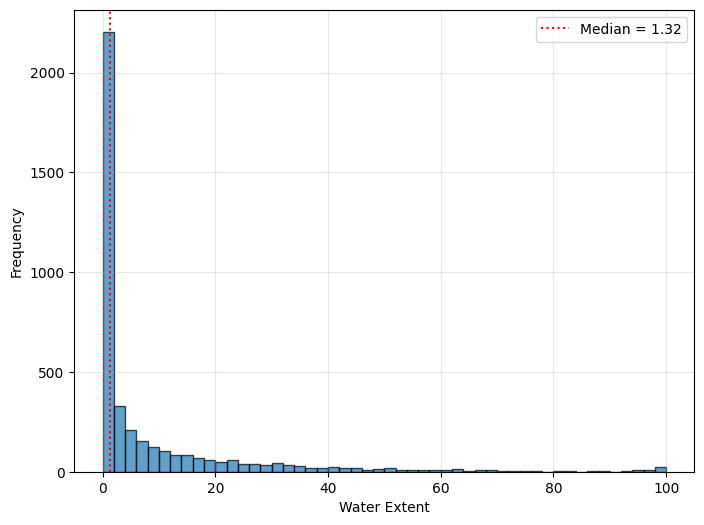

In [20]:
# How to deal with water extent outliers? 

wdpa_df = wdpa_df[wdpa_df['year'] == 2025]

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(wdpa_df['water_extent_pct'], bins=50, edgecolor='black', alpha=0.7)
med_extent = wdpa_df['water_extent_pct'].median()
ax.axvline(med_extent, color='red', ls=':', lw=1.5, label=f'Median = {med_extent:.2f}')
ax.legend()
ax.set_xlabel('Water Extent')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

fig.show()

## 6 — Export Data for Interactive Map
### Edge Extent Overtime

In [21]:
gdf = gpd.read_file(config.DATA_INTERMEDIATE / 'wdpa_filtered' / 'wdpa_filtered.shp')
gdf['WDPA_PID'] = gdf['WDPA_PID'].astype(str)

cols = ['WDPA_PID', 'ORIG_NAME', 'BIOME_NAME', 'trend_extent', 'trend_intensity', 'edge_extent', 'edge_intensity']
ext = extent_2025[cols].copy()
ext['WDPA_PID'] = ext['WDPA_PID'].astype(str)

subset = gdf[['WDPA_PID', 'geometry']].merge(ext, on='WDPA_PID', how='inner')

subset.to_file(config.DATA_PROCESSED / 'selected_pas.shp')
print(f'Saved {len(subset)} PAs to {config.DATA_PROCESSED / "selected_pas.shp"}')

Saved 4045 PAs to /workspace/data/processed/selected_pas.shp


In [22]:
import glob

# Load boundary point coordinates (pointID == 0)
transects = pd.read_csv(config.RESULTS_DIR / 'processed' / 'transects_final.csv')
transects['pointID'] = transects['pointID'].astype(float)
coords = transects.loc[transects['pointID'] == 0.0, ['WDPA_PID', 'transectID', 'x', 'y']]
coords = coords.rename(columns={'x': 'lon', 'y': 'lat'})
coords['WDPA_PID'] = coords['WDPA_PID'].astype(str)
coords['transectID'] = coords['transectID'].astype(str)
print(f'Boundary coords loaded: {len(coords):,}')

# Load all transect chunks and join coordinates
chunk_dir = config.RESULTS_RAW / f'{IDX}_raw' / 'transect_chunks'
chunks = sorted(glob.glob(str(chunk_dir / f'{IDX}_transect_chunk_*.parquet')))

parts = []
for f in chunks:
    df = pd.read_parquet(f, columns=['pt_0', 'edge']).reset_index()
    df['WDPA_PID'] = df['WDPA_PID'].astype(str)
    df['transectID'] = df['transectID'].astype(str)
    df = df.merge(coords, on=['WDPA_PID', 'transectID'], how='inner')
    parts.append(df[['WDPA_PID', 'year', 'pt_0', 'edge', 'lon', 'lat']])
    print(f'  {Path(f).name}: {len(df):,} rows')

export = pd.concat(parts, ignore_index=True)
print(f'\nTotal rows: {len(export):,}  |  PAs: {export["WDPA_PID"].nunique():,}')

out_path = config.RESULTS_DIR / f'{IDX}_boundary_points_yearly.csv'
export.to_csv(out_path, index=False)
print(f'Saved {out_path} ({out_path.stat().st_size / 1e6:.1f} MB)')

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/results/processed/transects_final.csv'